# Purpose

- Test how different transformations of the variables can lead to different outcomes


# Import packages


In [1]:
library(stats)
library(ggplot2)
library(patchwork)


# Generate transformed data


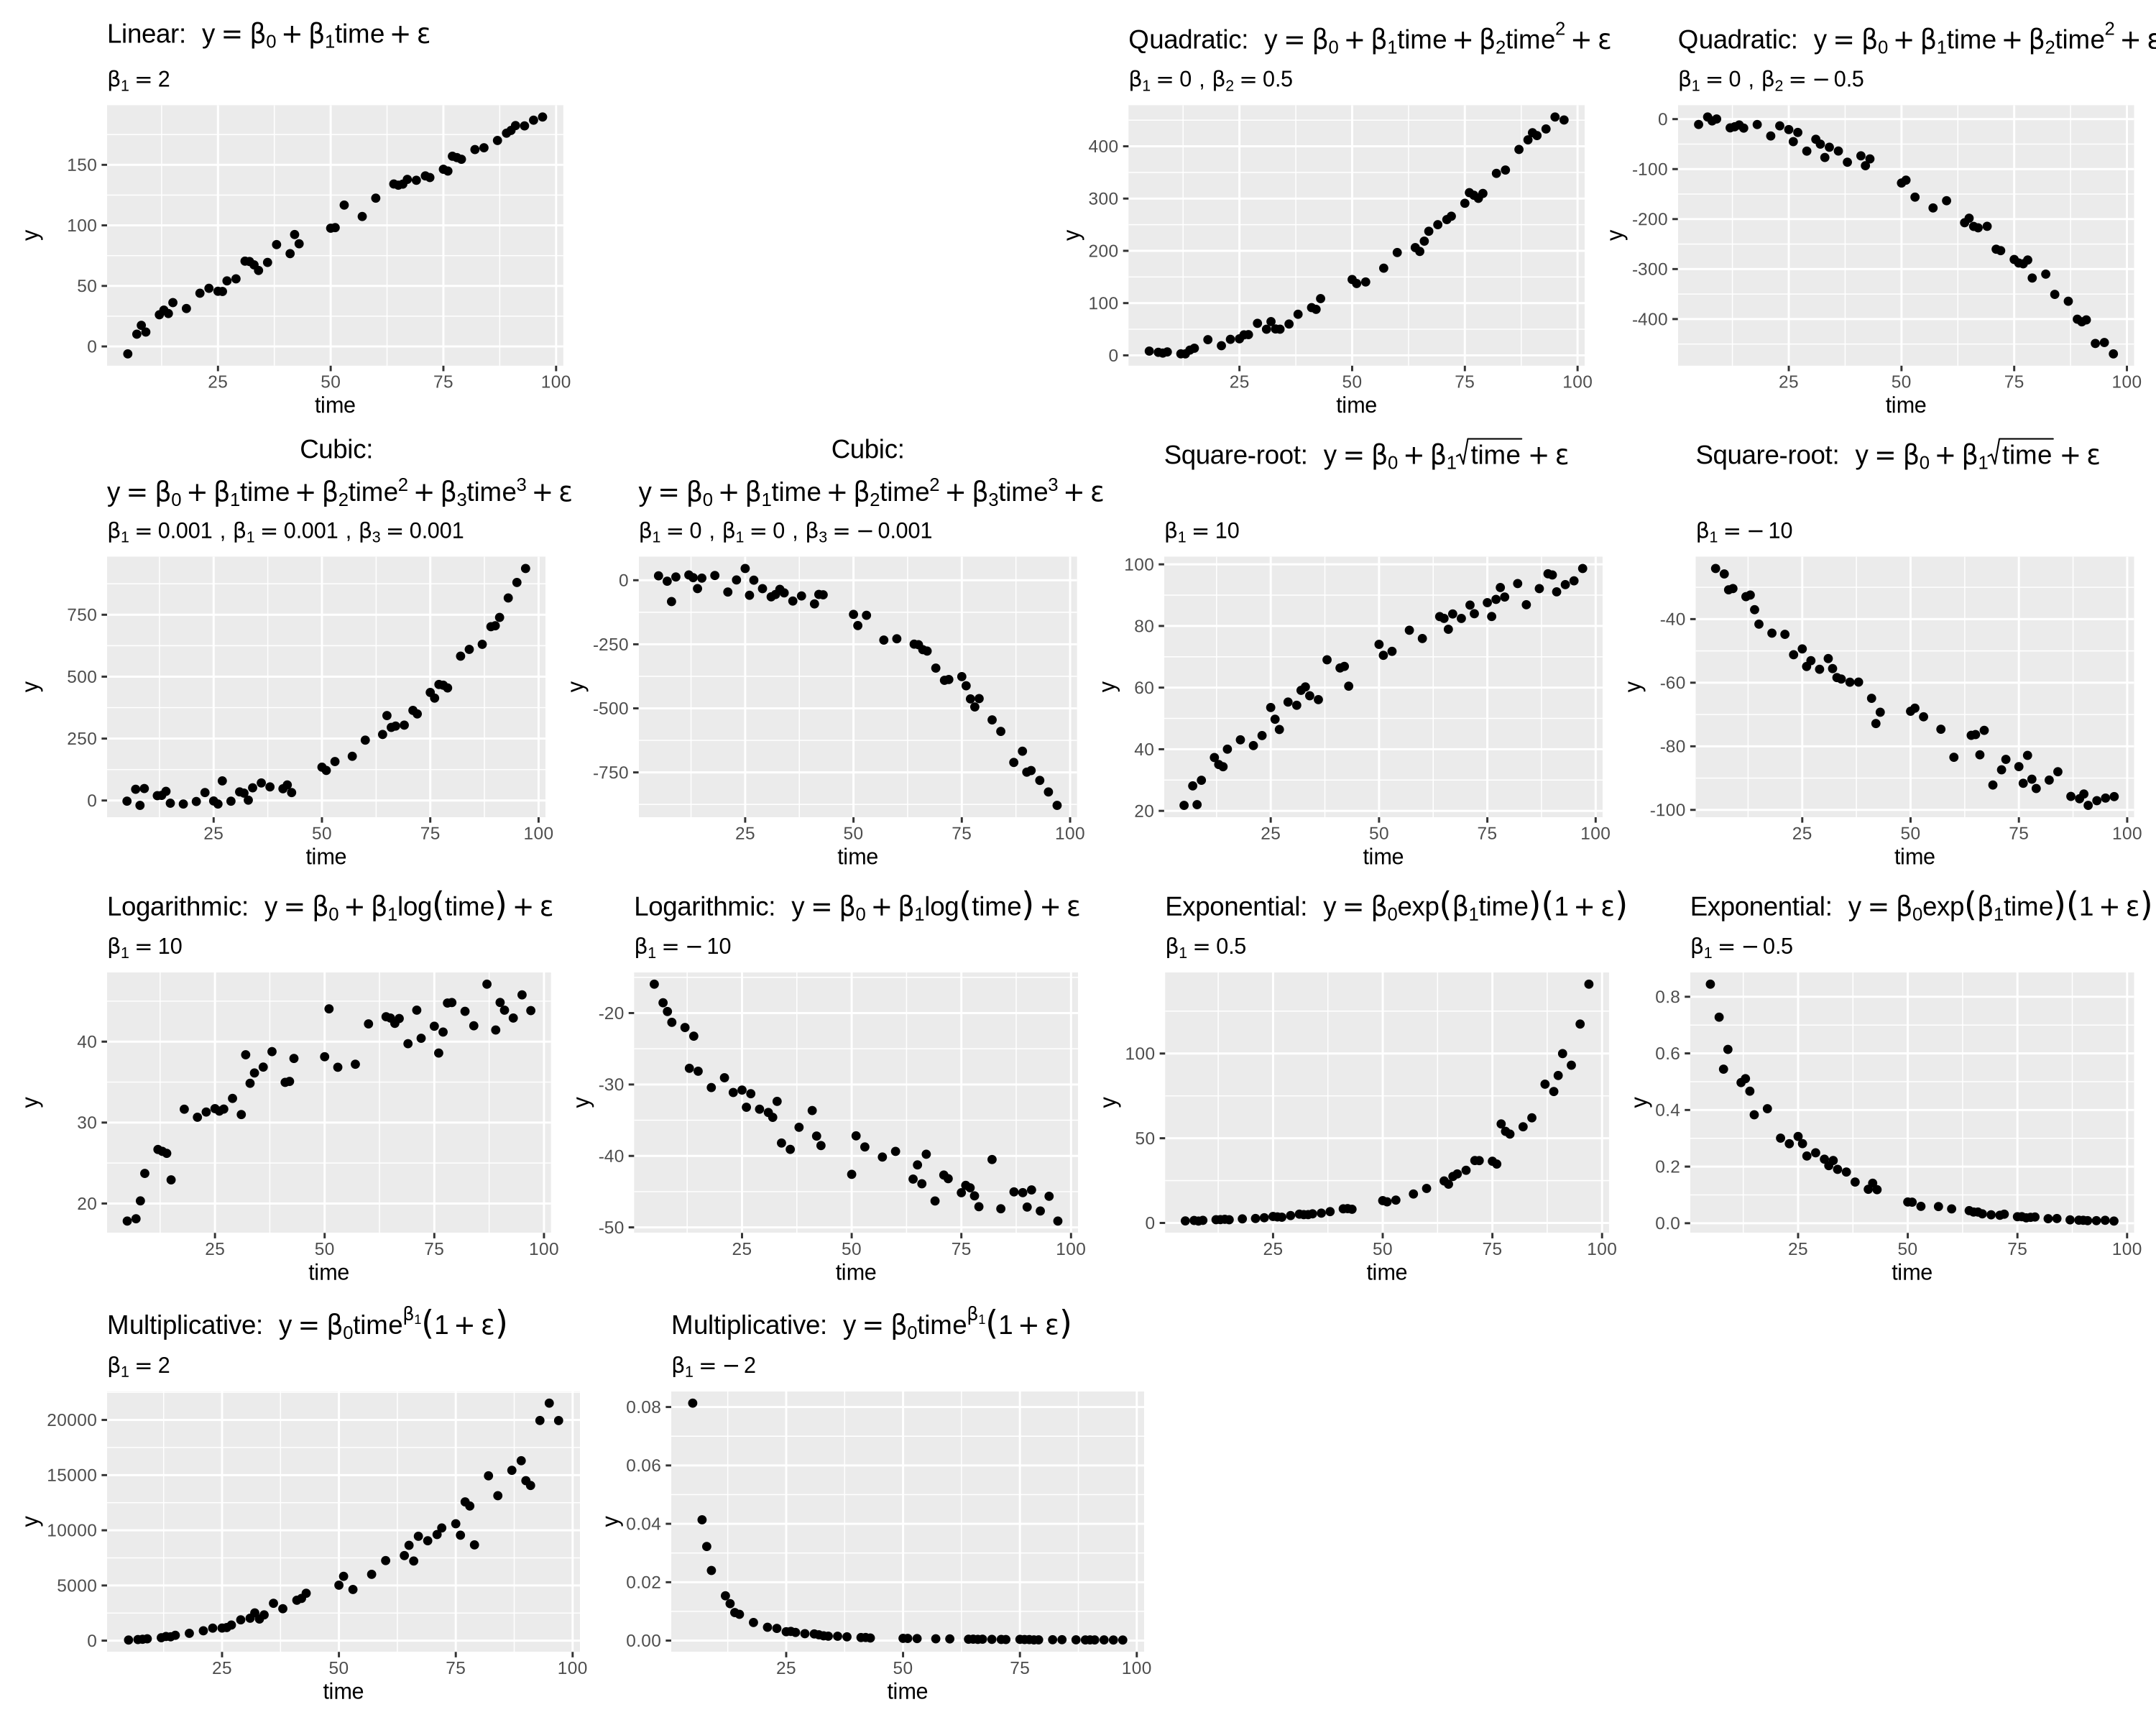

In [2]:
set.seed(123) # For reproducibility

# Generate a random progression of time values from 1 to 100
time <- sort(sample(1:100, 50, replace = FALSE))

# Generate y values with a linear relationship to time and some normal noise
y <- 2 * time + rnorm(50, mean = 0, sd = 5)
data_linear <- data.frame(time = time, y = y)

# Generate y values with a quadratic relationship to time and some normal noise
## increasing
y_quadratic <- 0.05 * time + 0.05 * time^2 + rnorm(50, mean = 0, sd = 10)
data_quadratic <- data.frame(time = time, y = y_quadratic)
## decreasing
y_quadratic_dec <- 0.05 * time + -0.05 * time^2 + rnorm(50, mean = 0, sd = 10)
data_quadratic_dec <- data.frame(time = time, y = y_quadratic_dec)

# Generate y values with a cubic relationship to time and some normal noise
## increasing
y_cubic <- 0.001 * time + 0.0001 * time^2 + 0.001 * time^3 + rnorm(50, mean = 0, sd = 25)
data_cubic <- data.frame(time = time, y = y_cubic)
## decreasing
y_cubic_dec <- 0.001 * time + 0.0001 * time^2 + -0.001 * time^3 + rnorm(50, mean = 0, sd = 25)
data_cubic_dec <- data.frame(time = time, y = y_cubic_dec)

# Generate y values with a square-root relationship to time and some normal noise
## increasing
y_sqrt <- 10 * sqrt(time) + rnorm(50, mean = 0, sd = 3)
data_sqrt <- data.frame(time = time, y = y_sqrt)
## decreasing
y_sqrt_dec <- -10 * sqrt(time) + rnorm(50, mean = 0, sd = 3)
data_sqrt_dec <- data.frame(time = time, y = y_sqrt_dec)

# Generate y values with a logarithmic relationship to time and some normal noise
## increasing
y_log <- 10 * log(time) + rnorm(50, mean = 0, sd = 2)
data_log <- data.frame(time = time, y = y_log)
## decreasing
y_log_dec <- -10 * log(time) + rnorm(50, mean = 0, sd = 2)
data_log_dec <- data.frame(time = time, y = y_log_dec)

# Generate y values with an exponential relationship to time and some normal noise
## increasing
y_exp <- exp(0.05 * time) * (1 + rnorm(50, mean = 0, sd = 0.1))
data_exp <- data.frame(time = time, y = y_exp)
## decreasing
y_exp_dec <- exp(-0.05 * time) * (1 + rnorm(50, mean = 0, sd = 0.1))
data_exp_dec <- data.frame(time = time, y = y_exp_dec)

# Generate y values with an multiplicative relationship to time and some normal noise
## increasing
y_mult <- 2 * (time^2) * (1 + rnorm(50, mean = 0, sd = 0.1))
data_mult <- data.frame(time = time, y = y_mult)

## decreasing
y_mult_dec <- 2 * (time^-2) * (1 + rnorm(50, mean = 0, sd = 0.1))
data_mult_dec <- data.frame(time = time, y = y_mult_dec)


options(repr.plot.width = 15, repr.plot.height = 12, repr.plot.res = 200)

# Create scatterplots for each dataset
plot_linear <- ggplot(data_linear, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Linear: " ~ y == beta[0] + beta[1] * time + epsilon)) +
    labs(subtitle = bquote(beta[1] == 2))

plot_quadratic <- ggplot(data_quadratic, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Quadratic: " ~ y == beta[0] + beta[1] * time + beta[2] * time^2 + epsilon)) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[2] == 0.5))
plot_quadratic_dec <- ggplot(data_quadratic_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Quadratic: " ~ y == beta[0] + beta[1] * time + beta[2] * time^2 + epsilon)) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[2] == -0.5))

plot_cubic <- ggplot(data_cubic, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote(atop("Cubic: ", y == beta[0] + beta[1] * time + beta[2] * time^2 + beta[3] * time^3 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 0.001 ~ "," ~ beta[1] == 0.001 ~ "," ~ beta[3] == 0.001))
plot_cubic_dec <- ggplot(data_cubic_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote(atop("Cubic: ", y == beta[0] + beta[1] * time + beta[2] * time^2 + beta[3] * time^3 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[1] == 0 ~ "," ~ beta[3] == -0.001))

plot_sqrt <- ggplot(data_sqrt, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Square-root: " ~ y == beta[0] + beta[1] * sqrt(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == 10))
plot_sqrt_dec <- ggplot(data_sqrt_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Square-root: " ~ y == beta[0] + beta[1] * sqrt(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == -10))

plot_log <- ggplot(data_log, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Logarithmic: " ~ y == beta[0] + beta[1] * log(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == 10))
plot_log_dec <- ggplot(data_log_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Logarithmic: " ~ y == beta[0] + beta[1] * log(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == -10))

plot_exp <- ggplot(data_exp, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Exponential: " ~ y == beta[0] * exp(beta[1] * time) * (1 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 0.5))
plot_exp_dec <- ggplot(data_exp_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Exponential: " ~ y == beta[0] * exp(beta[1] * time) * (1 + epsilon))) +
    labs(subtitle = bquote(beta[1] == -0.5))

plot_mult <- ggplot(data_mult, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Multiplicative: " ~ y == beta[0] * time^beta[1] * (1 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 2))
plot_mult_dec <- ggplot(data_mult_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Multiplicative: " ~ y == beta[0] * time^beta[1] * (1 + epsilon))) +
    labs(subtitle = bquote(beta[1] == -2))

# Combine all plots using patchwork
(plot_linear | plot_spacer() | plot_quadratic | plot_quadratic_dec) /
    (plot_cubic | plot_cubic_dec | plot_sqrt | plot_sqrt_dec) /
    (plot_log | plot_log_dec | plot_exp | plot_exp_dec) /
    (plot_mult | plot_mult_dec | plot_spacer() | plot_spacer())


# Linear model


In [22]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time, data = data_linear)
model_quadratic <- lm(y ~ time, data = data_quadratic)
model_quadratic_dec <- lm(y ~ time, data = data_quadratic_dec)
model_cubic <- lm(y ~ time, data = data_cubic)
model_cubic_dec <- lm(y ~ time, data = data_cubic_dec)
model_sqrt <- lm(y ~ time, data = data_sqrt)
model_sqrt_dec <- lm(y ~ time, data = data_sqrt_dec)
model_log <- lm(y ~ time, data = data_log)
model_log_dec <- lm(y ~ time, data = data_log_dec)
model_exp <- lm(y ~ time, data = data_exp)
model_exp_dec <- lm(y ~ time, data = data_exp_dec)
model_mult <- lm(y ~ time, data = data_mult)
model_mult_dec <- lm(y ~ time, data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [23]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_linear <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_linear)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9922407
2,Quadratic,0.9519875
3,Quadratic Dec,0.9419899
4,Cubic,0.8456979
5,Cubic Dec,0.8611056
6,Square-root,0.9519183


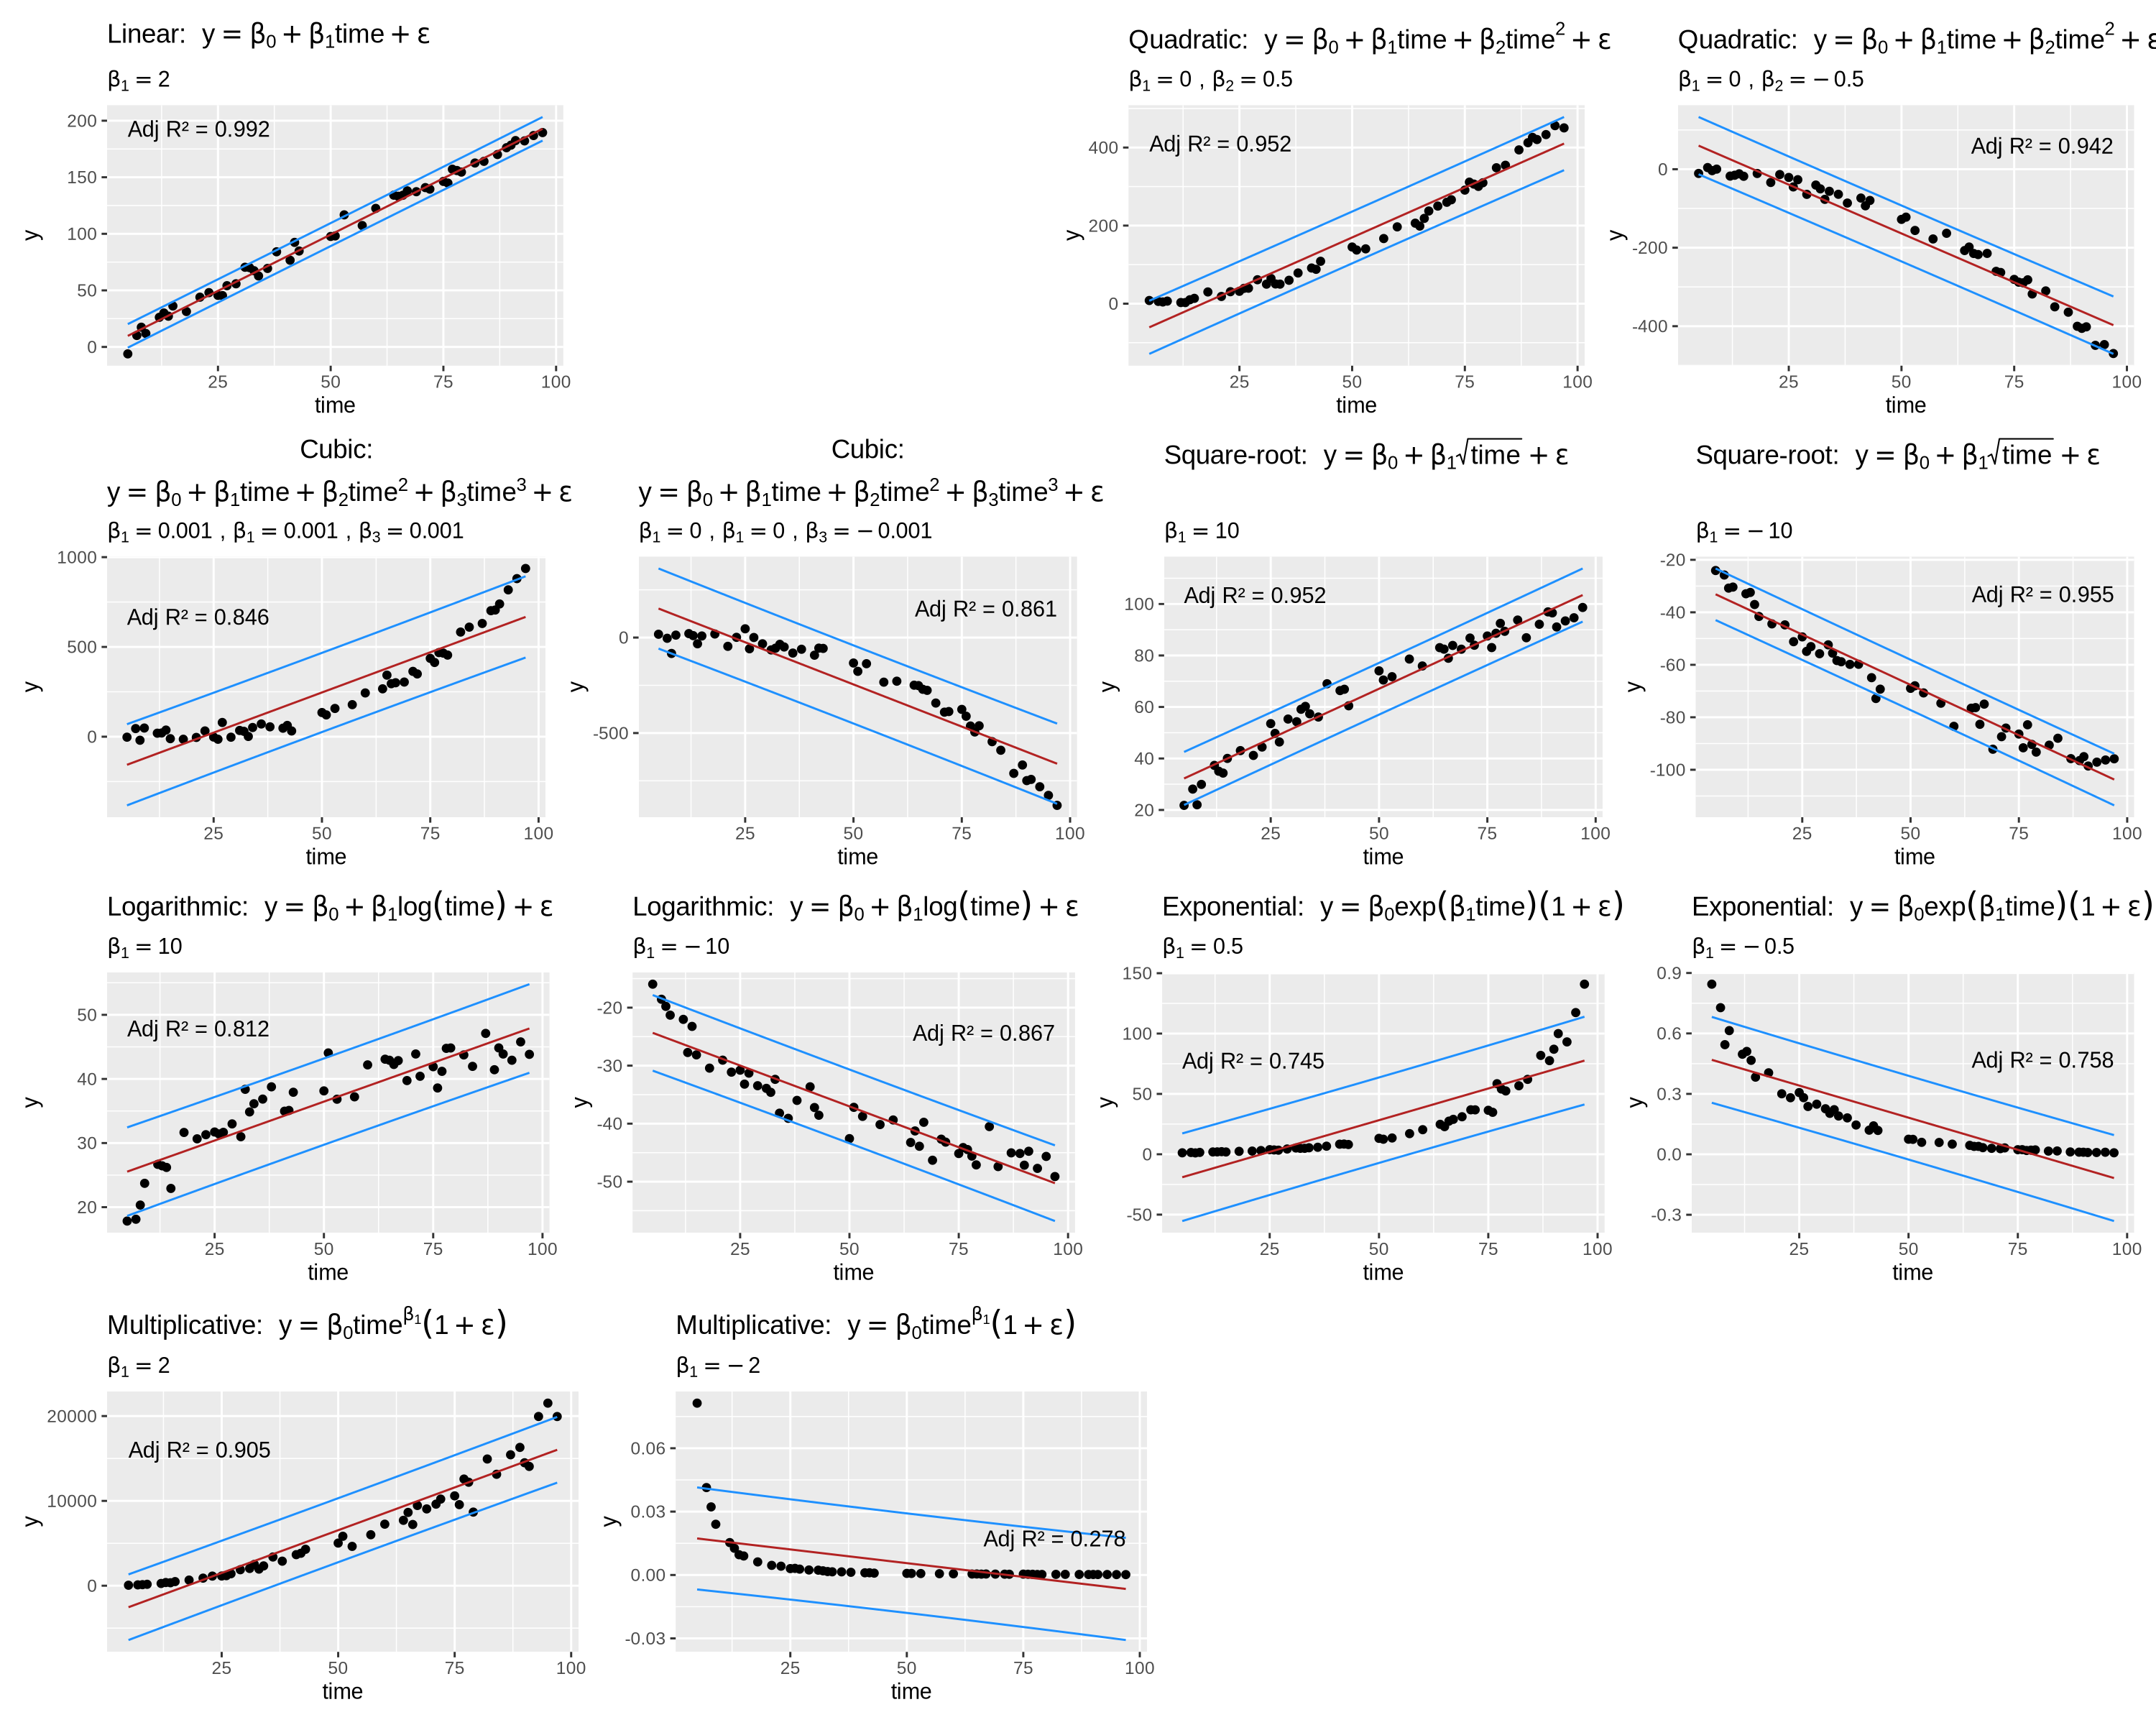

In [19]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Quadratic model


In [24]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time + I(time^2), data = data_linear)
model_quadratic <- lm(y ~ time + I(time^2), data = data_quadratic)
model_quadratic_dec <- lm(y ~ time + I(time^2), data = data_quadratic_dec)
model_cubic <- lm(y ~ time + I(time^2), data = data_cubic)
model_cubic_dec <- lm(y ~ time + I(time^2), data = data_cubic_dec)
model_sqrt <- lm(y ~ time + I(time^2), data = data_sqrt)
model_sqrt_dec <- lm(y ~ time + I(time^2), data = data_sqrt_dec)
model_log <- lm(y ~ time + I(time^2), data = data_log)
model_log_dec <- lm(y ~ time + I(time^2), data = data_log_dec)
model_exp <- lm(y ~ time + I(time^2), data = data_exp)
model_exp_dec <- lm(y ~ time + I(time^2), data = data_exp_dec)
model_mult <- lm(y ~ time + I(time^2), data = data_mult)
model_mult_dec <- lm(y ~ time + I(time^2), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [25]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_quad <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_quad)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9930458
2,Quadratic,0.9965999
3,Quadratic Dec,0.9941927
4,Cubic,0.9888866
5,Cubic Dec,0.9857433
6,Square-root,0.9816979


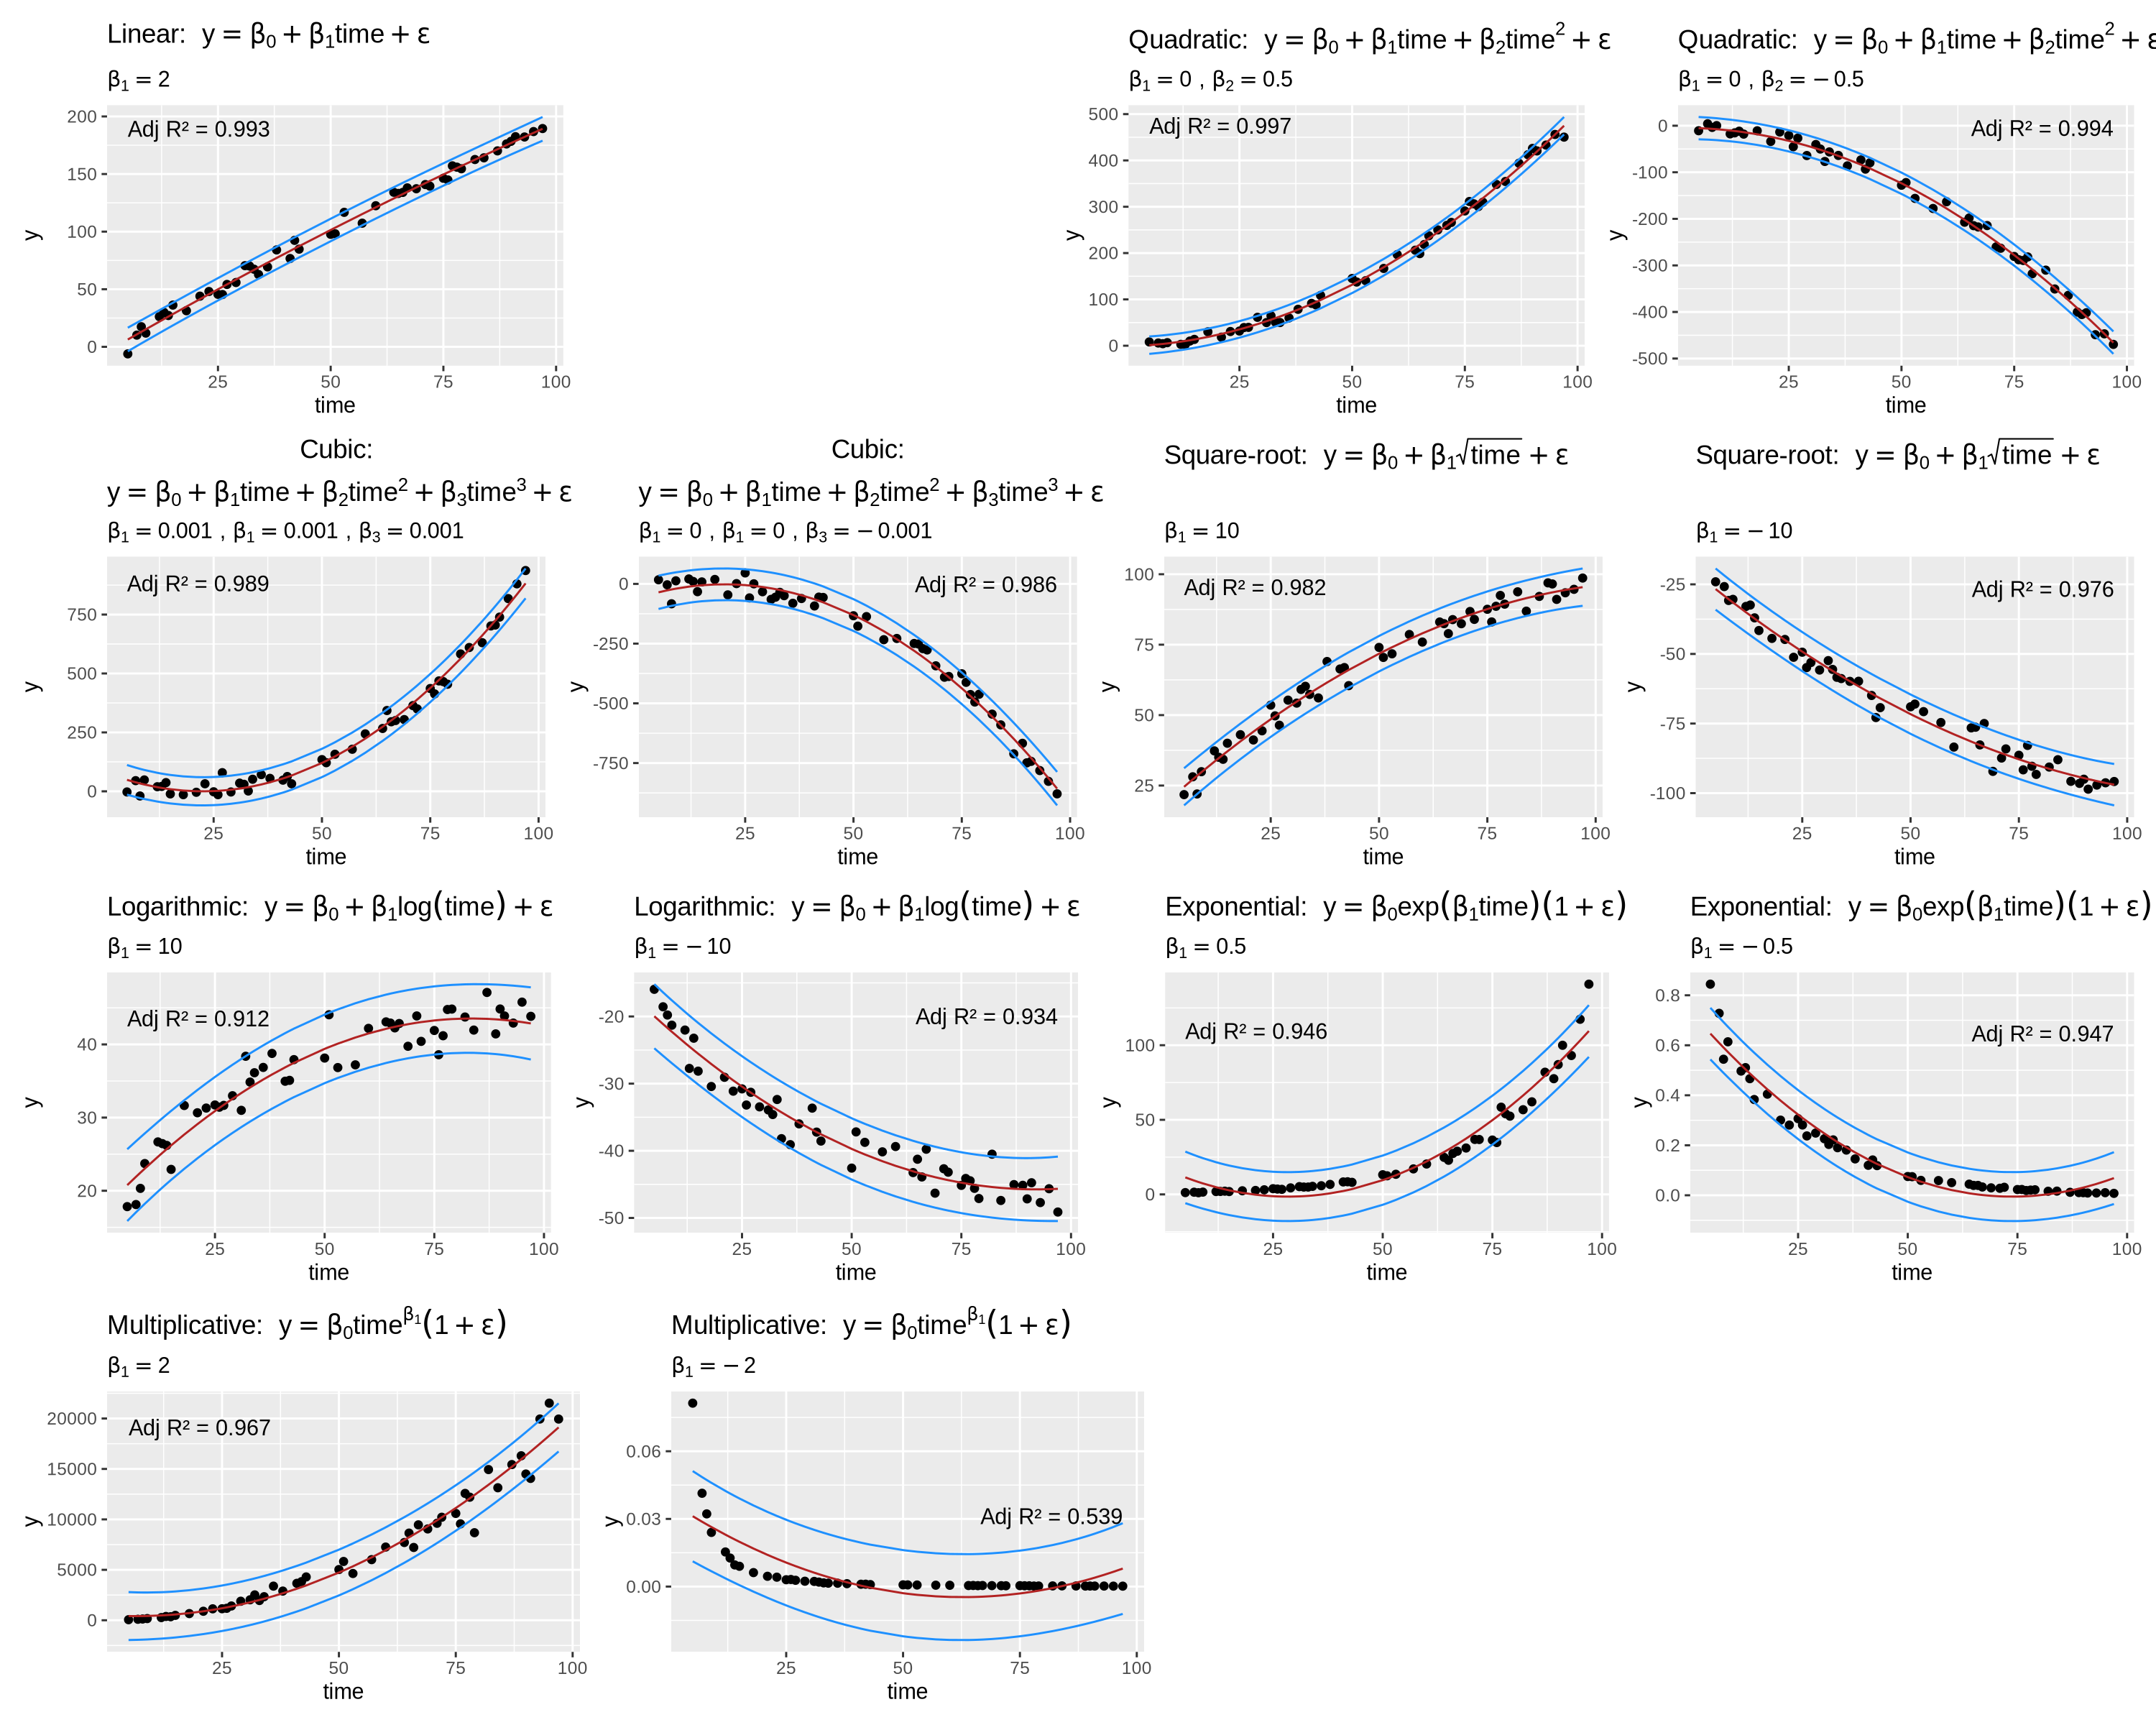

In [11]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Cubic model


In [26]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time + I(time^2) + I(time^3), data = data_linear)
model_quadratic <- lm(y ~ time + I(time^2) + I(time^3), data = data_quadratic)
model_quadratic_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_quadratic_dec)
model_cubic <- lm(y ~ time + I(time^2) + I(time^3), data = data_cubic)
model_cubic_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_cubic_dec)
model_sqrt <- lm(y ~ time + I(time^2) + I(time^3), data = data_sqrt)
model_sqrt_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_sqrt_dec)
model_log <- lm(y ~ time + I(time^2) + I(time^3), data = data_log)
model_log_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_log_dec)
model_exp <- lm(y ~ time + I(time^2) + I(time^3), data = data_exp)
model_exp_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_exp_dec)
model_mult <- lm(y ~ time + I(time^2) + I(time^3), data = data_mult)
model_mult_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [27]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_cubic <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_cubic)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9930411
2,Quadratic,0.9966288
3,Quadratic Dec,0.9942408
4,Cubic,0.9913957
5,Cubic Dec,0.9885879
6,Square-root,0.9824622


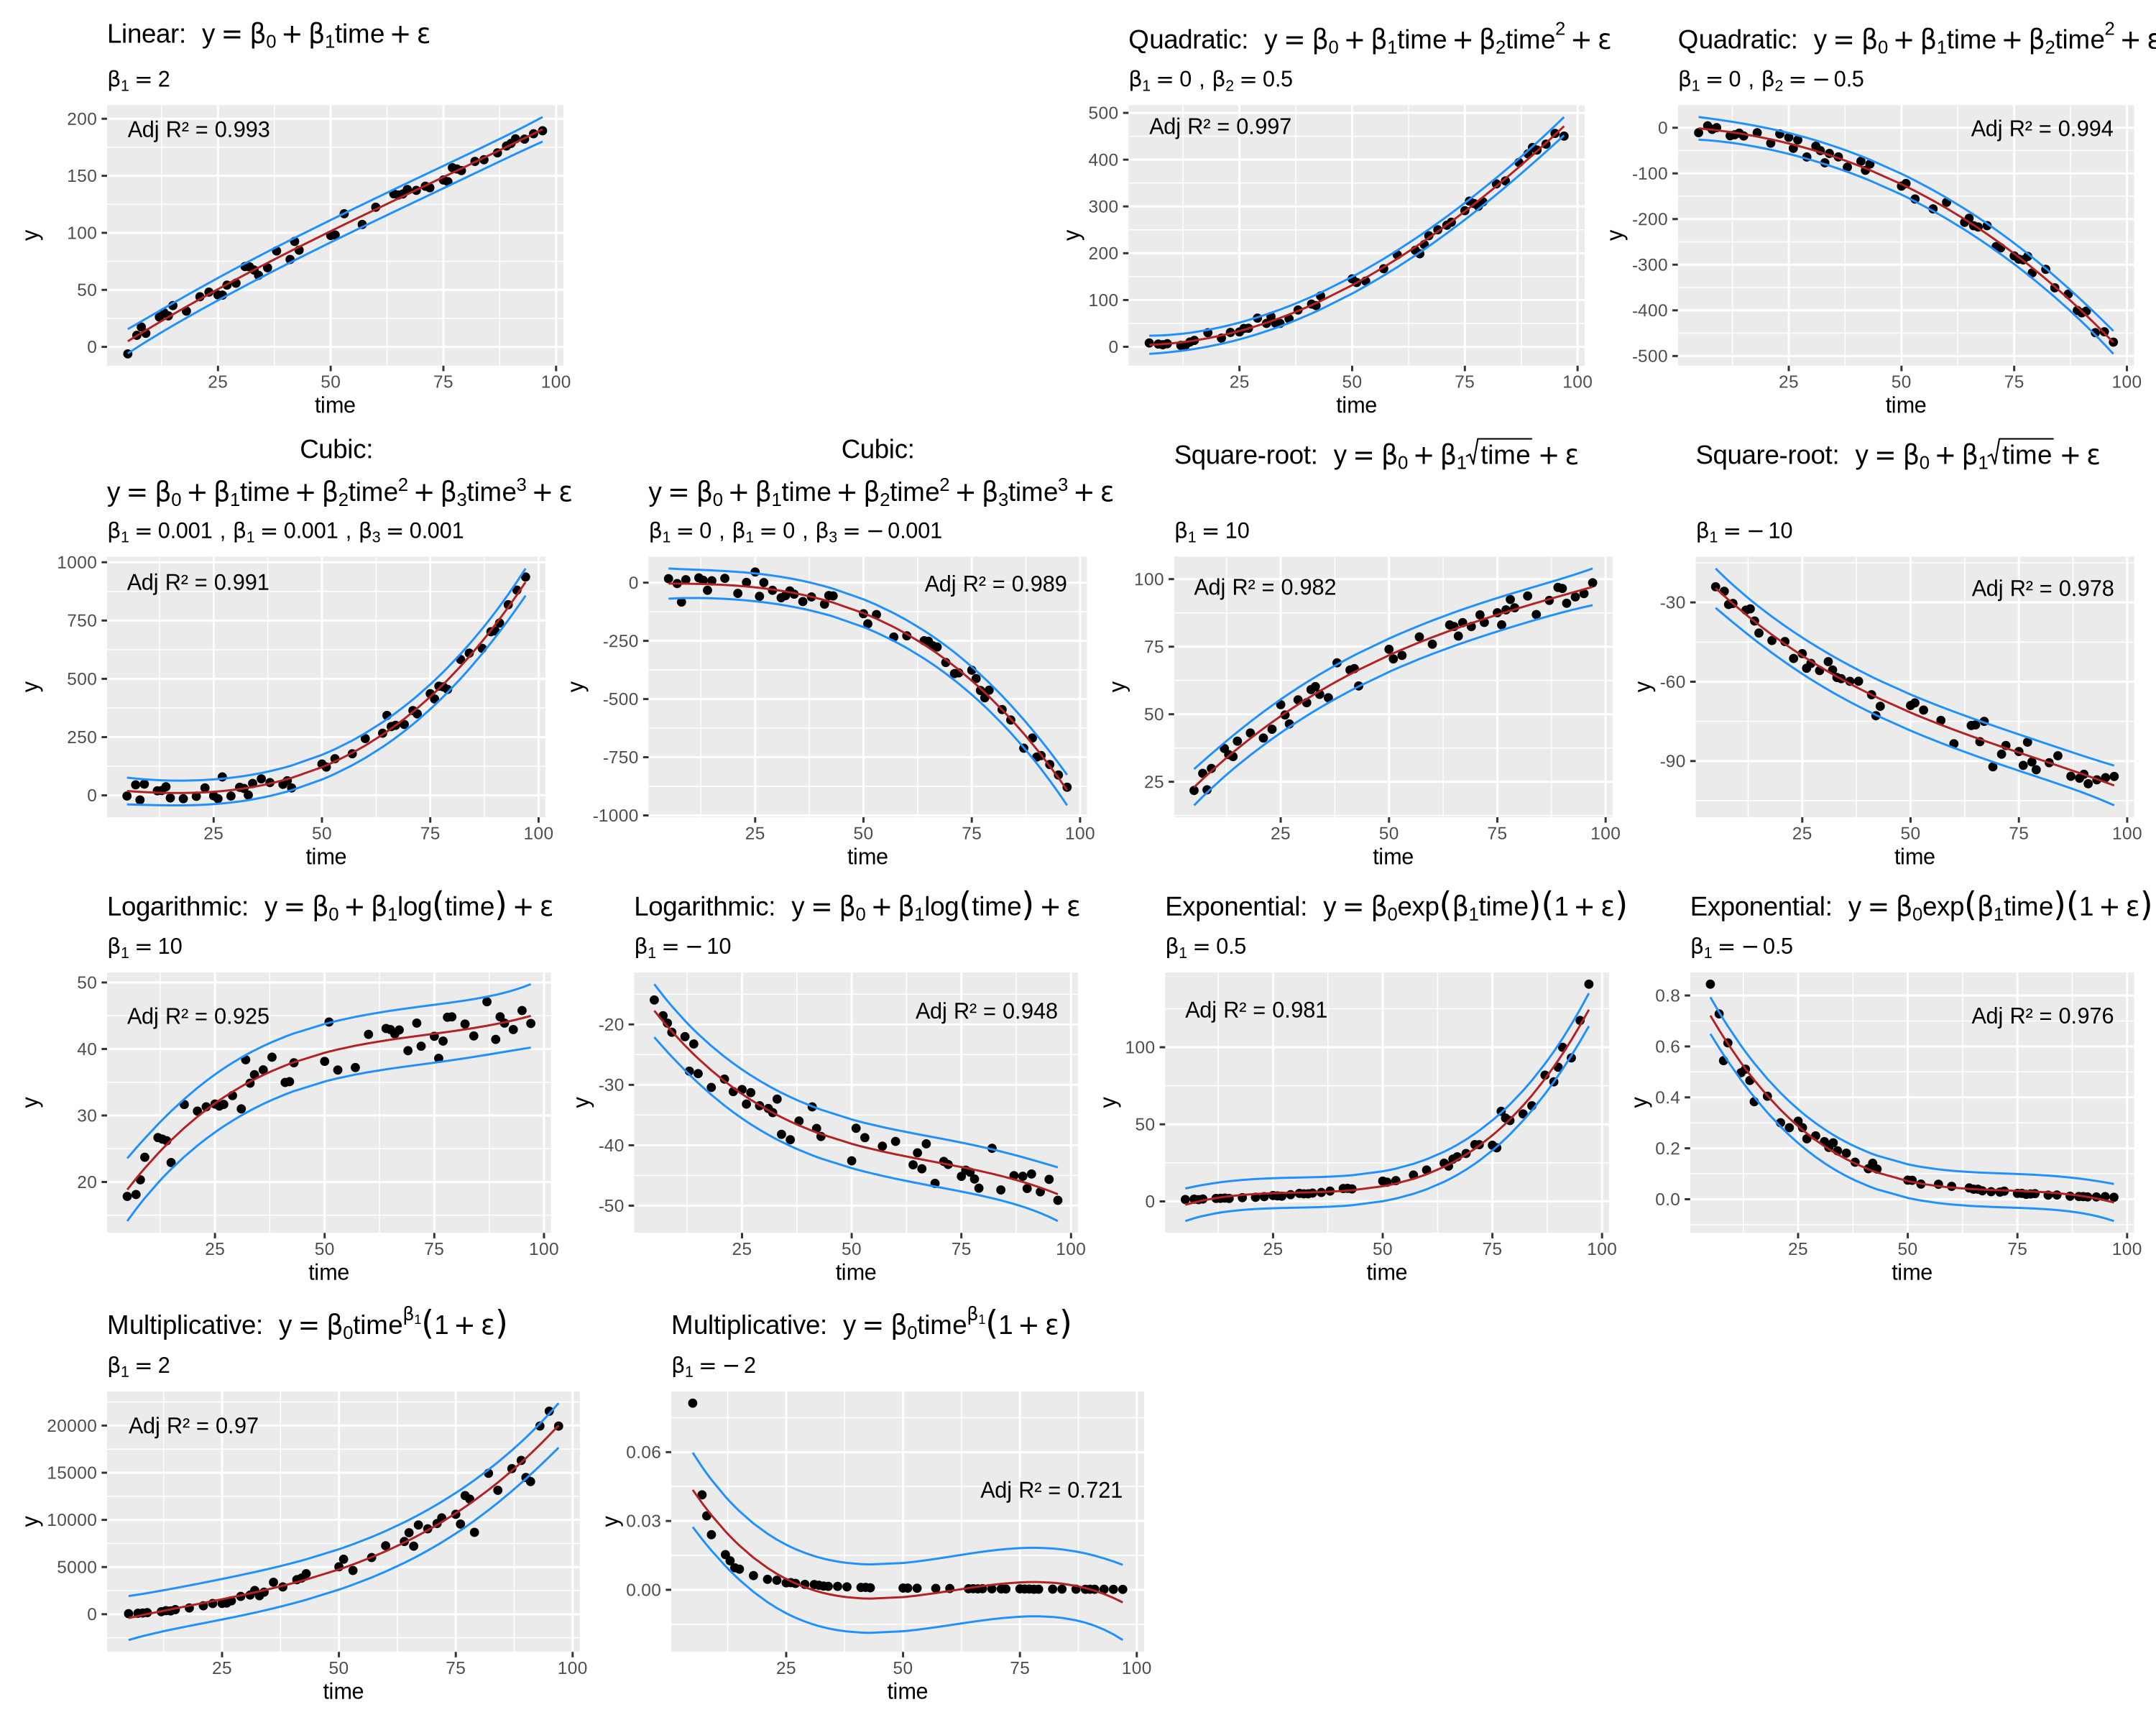

In [28]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())
